









# 02 — Used Car Price Predictor: Model Training and Evaluation

This notebook turns the cleaned dataset from `01_eda_modeling.ipynb` into a working machine learning model.

The goal is not to test every possible model. The goal is to build a clean, reproducible modeling workflow that compares a few important regression models fairly.

## Project objective

Predict used-car listing prices from vehicle features such as make, model, year, mileage, fuel type, transmission, drivetrain, engine size, and location.

## Main question

Which regression model gives the best balance of prediction accuracy, reliability, and deployability for a used-car price prediction app?

## Modeling task

This is a **supervised regression** problem because the target variable, `price`, is numerical.

## Candidate models

This notebook compares:

- Dummy Regressor baseline
- Linear Regression
- Ridge Regression
- Decision Tree Regressor
- Random Forest Regressor
- Extra Trees Regressor
- XGBoost Regressor, if installed

## Main evaluation metrics

- **MAE**: average dollar error
- **RMSE**: penalizes larger mistakes more heavily
- **R²**: amount of price variation explained by the model

For this project, **MAE is the primary metric** because it is easiest to interpret in real pricing terms.

## Final output

The final model will be saved as:

```text
../models/car_price_pipeline.joblib
```

This saved pipeline can later be loaded by a Django app to make price predictions.

# 02 — Used Car Price Predictor: Model Training and Evaluation

1. Imports

2. Load processed dataset

3. Feature engineering

4. Define target and predictor variables

5. Train/test split

6. Preprocessing pipeline

7. Baseline model

8. Model training and comparison

9. Select best model

10. Actual vs predicted plot

11. Residual analysis

12. Save final model pipeline

13. Notebook conclusion

## Load Dataset

We will perform imputation after splitting our dataset into testing and training sets in order to avoid data leakage. So we perform feature engineering on `cleaned.csv`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned.csv", low_memory=False)

df = df.replace({pd.NA: np.nan})
df.dtypes

id                    str
vin                   str
price             float64
miles             float64
stock_no              str
year              float64
make                  str
model                 str
trim                  str
body_type             str
vehicle_type          str
drivetrain            str
transmission          str
fuel_type             str
engine_size       float64
engine_block          str
seller_name           str
street                str
city                  str
state                 str
zip                   str
miles_was_zero      int64
dtype: object

### Performing Feature Engineering
Determining which features should be included in the training and the testing set

In [3]:
from datetime import datetime

# Dynamically fetch the current calendar year (e.g., 2026, 2027, etc.)
CURRENT_YEAR = datetime.now().year

df_model = df.copy()

# 1. Car age column
if "year" in df_model.columns:
    df_model["car_age"] = CURRENT_YEAR - df_model["year"]
    
    # Safety Guardrail: If data has a typo (e.g., year 2030), set age to NaN 
    # instead of a negative number, allowing the imputer to handle it safely.
    df_model.loc[df_model["car_age"] < 0, "car_age"] = np.nan

# 2. Miles per year column
if {"miles", "car_age"}.issubset(df_model.columns):
    # Instead of replacing 0 with 1 (which slightly distorts data for brand new cars),
    # calculate miles_per_year only where car_age > 0. If it's 0, leave it as NaN.
    df_model["miles_per_year"] = np.where(
        df_model["car_age"] > 0, 
        df_model["miles"] / df_model["car_age"], 
        np.nan
    )

# 3. Model Trim column
if {"model", "trim"}.issubset(df_model.columns):
    # Enforce string type, lowercasing, and whitespace stripping to prevent syntax duplicates
    clean_model = df_model["model"].astype("str").fillna("unknown").str.lower().str.strip()
    clean_trim = df_model["trim"].astype("str").fillna("unknown").str.lower().str.strip()
    
    df_model["model_trim"] = clean_model + " " + clean_trim

# 4. Region extraction from ZIP/Postal code
if "zip" in df_model.columns:
    df_model["region"] = df_model["zip"].astype("str").str.strip().str[:3]

# 5. Rename state to province
df_model = df_model.rename(columns={'state':'province'})

df_model.shape

(358434, 26)

In [4]:
drop_cols = [
    "id",
    "vin",
    "seller_name",
    "street",
    "stock_no",
    "zip",
    "model",
    "trim"
]

for cols in drop_cols:
    if cols in df_model.columns:
        df_model.drop(columns=cols, inplace=True)

df_model.shape

(358434, 18)

In [5]:
df_model.head()

,price,miles,year,make,body_type,vehicle_type,drivetrain,transmission,fuel_type,engine_size,engine_block,city,province,miles_was_zero,car_age,miles_per_year,model_trim,region
0,179999.0,9966.0,2017.0,acura,coupe,car,4wd,automatic,electric / premium unleaded,3.5,v,edmundston,nb,0,9.0,1107.333333,nsx base,e3v
1,179995.0,5988.0,2017.0,acura,coupe,car,4wd,automatic,electric / premium unleaded,3.5,v,notre-dame-des-pins,qc,0,9.0,665.333333,nsx base,g0m
2,168528.0,24242.0,2017.0,acura,coupe,car,4wd,automatic,electric / premium unleaded,3.5,v,coquitlam,bc,0,9.0,2693.555556,nsx base,v3k
3,220000.0,6637.0,2020.0,acura,coupe,car,4wd,automatic,electric / premium unleaded,3.5,v,pickering,on,0,6.0,1106.166667,nsx base,l1v
4,220000.0,6637.0,2020.0,acura,coupe,car,4wd,automatic,electric / premium unleaded,3.5,v,pickering,on,0,6.0,1106.166667,nsx base,l1v


Saving `df_model.csv`

In [7]:
df_model.to_csv("../data/processed.csv", index=False)

## Define Target and Predictor variables

In [8]:
from sklearn.model_selection import train_test_split

TARGET = "price"

X = df_model.drop(columns=[TARGET]).copy()
y = df_model[TARGET].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (358434, 17)
y shape: (358434,)


## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42)

print("Number of rows in X_train:", X_train.shape[0])
print("Number of rows in y_test:", y_test.shape[0])

df_model.info()

Number of rows in X_train: 286747
Number of rows in y_test: 71687
<class 'pandas.DataFrame'>
RangeIndex: 358434 entries, 0 to 358433
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   price           358434 non-null  float64
 1   miles           335025 non-null  float64
 2   year            358419 non-null  float64
 3   make            358434 non-null  str    
 4   body_type       327710 non-null  str    
 5   vehicle_type    323765 non-null  str    
 6   drivetrain      325145 non-null  str    
 7   transmission    327945 non-null  str    
 8   fuel_type       295953 non-null  str    
 9   engine_size     294138 non-null  float64
 10  engine_block    293740 non-null  str    
 11  city            351849 non-null  str    
 12  province        351789 non-null  str    
 13  miles_was_zero  358434 non-null  int64  
 14  car_age         358419 non-null  float64
 15  miles_per_year  335012 non-null  float64
 16  m

## Preprocessing Pipeline 

Numeric columns are imputed with the median, and Categorical columns are filled with `unknown` and one-hot encoded.

Use `ColumnTransformer` later to combine these two pipelines inside one reproducible preprocessing object.

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)


Numeric columns: ['miles', 'year', 'engine_size', 'miles_was_zero', 'car_age', 'miles_per_year']
Categorical columns: ['make', 'body_type', 'vehicle_type', 'drivetrain', 'transmission', 'fuel_type', 'engine_block', 'city', 'province', 'model_trim', 'region']


In [11]:
categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

X[categorical_features].nunique().sort_values(ascending=False)

model_trim      5998
region           963
city             758
make              57
fuel_type         24
body_type         21
province          15
engine_block       3
drivetrain         3
vehicle_type       2
transmission       2
dtype: int64

We see that using a regular one-hot encoder would lead to a high cardinality dataset leading to inaccurate predictions.
Our next steps are to perform analysis on where most of the coverage % are for some frequency for each of the high cardinal features, specifically, `model_trim`, `region` and `city`.

In [13]:
high_cardinality_features = [
    "model_trim",
    "region",
    "city"
]

# Frequency thresholds to test
minimum_frequencies = [25, 50, 100, 200]

coverage_results = []

for feature in high_cardinality_features:
    if feature not in df_model.columns:
        print(f"Skipping {feature}: not found in df_model")
        continue

    value_counts = df_model[feature].value_counts(dropna=False)
    total_rows = value_counts.sum()

    for freq in minimum_frequencies:
        categories_kept = (value_counts >= freq).sum()

        rows_covered = value_counts[value_counts >= freq].sum()

        row_coverage_percent = (rows_covered / total_rows) * 100

        coverage_results.append({
            "feature": feature,
            "minimum_frequency": freq,
            "categories_kept": categories_kept,
            "row_coverage_percent": row_coverage_percent
        })

coverage_frequency_df = pd.DataFrame(coverage_results)

coverage_frequency_df

,feature,minimum_frequency,categories_kept,row_coverage_percent
0,model_trim,25,1703,93.102217
1,model_trim,50,1175,87.935296
2,model_trim,100,720,78.965444
3,model_trim,200,395,66.346106
4,region,25,836,99.519856
5,region,50,727,98.389662
6,region,100,566,95.148619
7,region,200,410,88.923484
8,city,25,555,99.300011
9,city,50,421,97.978149


Now we will create a Pipeline for `model_trim`, `region` and `city`, since they are high cardinal features. We will also be dropping `model` and `trim` as we no longer need it given `model_trim`.

As we can see a model_trim frequency of atleast 100 covers ~80% of total rows,
 region frequency of 200 covers ~90% of total rows and city frequency of 200% covers ~93% of total rows. 

In [12]:
cat_columns_to_drop = [
    'model_trim' , 'region' , 'city' ,
    'model', 'trim'
]

low_cardinality_features = [
    col for col in categorical_cols
    if col not in cat_columns_to_drop
]

# High-cardinality categorical columns with separate transformers
model_trim_features = ["model_trim"]
region_features = ["region"]
city_features = ["city"]

# Final selected features
selected_features = (
    numeric_cols
    + low_cardinality_features
    + model_trim_features
    + region_features
    + city_features
)

selected_features = list(dict.fromkeys(selected_features))


# Remove accidental duplicates
selected_features = list(dict.fromkeys(selected_features))

print("Numeric columns:")
print(numeric_cols)

print("\nLow-cardinality categorical columns:")
print(low_cardinality_features)

print("\nSpecial high-cardinality columns:")
print(model_trim_features + region_features + city_features)

print("\nDropped columns:")
print(["model", "trim"])


Numeric columns:
['miles', 'year', 'engine_size', 'miles_was_zero', 'car_age', 'miles_per_year']

Low-cardinality categorical columns:
['make', 'body_type', 'vehicle_type', 'drivetrain', 'transmission', 'fuel_type', 'engine_block', 'province']

Special high-cardinality columns:
['model_trim', 'region', 'city']

Dropped columns:
['model', 'trim']


## Building the Pipeline

Defining each Pipeline first and then concatenating with Columntransformer()

In [ ]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]
)

low_cardinality_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

#
model_trim_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=50
    ))
])

region_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=100
    ))
])

city_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=100
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_transformer, numeric_cols),

    ("low_cardinality_categorical",
     low_cardinality_categorical_transformer,
     low_cardinality_features),

    ("model_trim",
     model_trim_transformer,
     model_trim_features),

    ("region",
     region_transformer,
     region_features),

    ("city",
     city_transformer,
     city_features)
])

## Evaluation Function

We will use MAE, RMSE and R².

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_model(model, X_test, y_test):
    prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)

    return {
        "MAE" : mae,
        "RMSE" : rmse,
        "R2" : r2
    }

## Baseline Model 

Before training any models, I create a baseline using DummyRegressor.

This model simply predicts the median price every time. I expect any of the other models to beat this.

In [ ]:
from sklearn.dummy import DummyRegressor

baseline_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="median"))
])

baseline_pipeline.fit(X_train, y_train)

baseline_results = evaluate_regression_model(baseline_pipeline, X_test, y_test)
baseline_results

{'MAE': 11661.111163809337,
 'RMSE': np.float64(20668.25731665551),
 'R2': -0.03999402911186789}

## Training Candidate models

I compare a set of important models, Linear Regression, Ridge Regression, Decision Trees, Random Forest, Extra Trees Regression, and XGBoost.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),   
    "Decision Tree": DecisionTreeRegressor(random_state=10, max_depth=20),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=1,
        min_samples_split=2,
        max_features=1.0,
        bootstrap=True,
        max_samples=0.8,
        n_jobs=-1,
        random_state=42,
        verbose = 2
    ),
    "XGBoost Strong GPU": XGBRegressor(
        n_estimators=1500,
        learning_rate=0.02,
        max_depth=8,
        min_child_weight=1,
        gamma=0,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1,
        reg_alpha=0,
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        device="cuda",
        random_state=42,
        n_jobs=-1
    )
    
}


In [ ]:
results = []
fitted_models = {}

for name, regressor in models.items():
    print(f"Training {name}...")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", regressor)    
    ])

    pipeline.fit(X_train, y_train)

    metrics = evaluate_regression_model(pipeline, X_test, y_test)
    metrics["Model"] = name

    results.append(metrics)
    fitted_models[name] = pipeline
    
results_df = pd.DataFrame(results)
results_df = results_df[["Model", "MAE", "RMSE", "R2"]]
results_df.sort_values("MAE")



## 10. Model comparison

I rank models mainly by MAE because the project is a price prediction problem. A lower MAE means the model is less wrong in dollar terms on average.

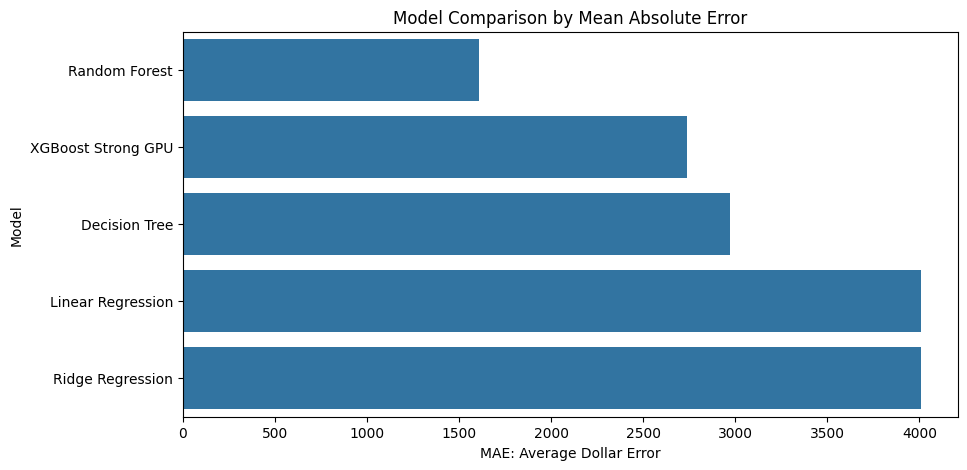

In [ ]:
results_df_sorted = results_df.sort_values("MAE").reset_index(drop=True)
results_df_sorted

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df_sorted,
    x="MAE",
    y="Model"
)

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("MAE: Average Dollar Error")
plt.ylabel("Model")
plt.show()

## 11. Select the best model

The best model is selected using the lowest MAE. I store it as `best_model` so I can analyze predictions and save it for deployment.


In [ ]:
best_model_name = results_df_sorted.loc[0, "Model"]
best_model = fitted_models[best_model_name]

print("Best model:", best_model_name)
results_df_sorted.head(1)

Best model: Random Forest


,Model,MAE,RMSE,R2
0,Random Forest,1610.922,5139.042976,0.935703


In [ ]:
y_pred = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "actual_price": y_test,
    "predicted_price": y_pred
})

comparison_df.head(3)


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.3s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    3.8s finished


,actual_price,predicted_price
122329,16995.0,21012.000000
241204,16495.0,15184.033333
172935,18988.0,18665.813333


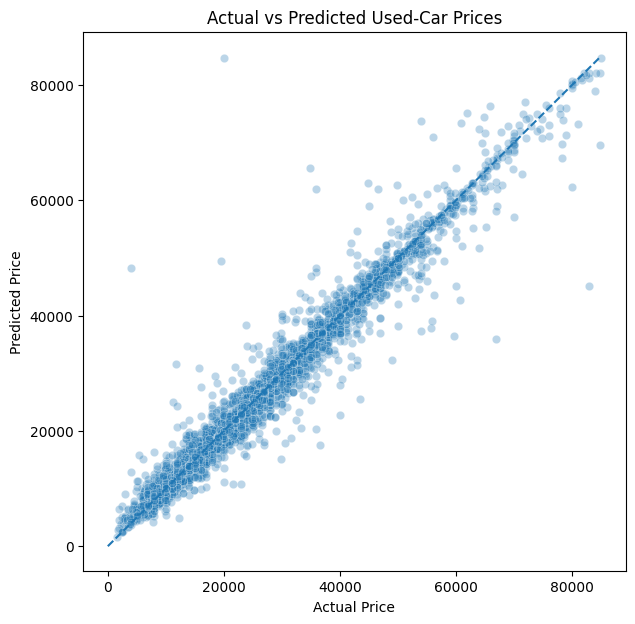

In [ ]:
price_99 = comparison_df["actual_price"].quantile(0.99)

plot_df = comparison_df[
    (comparison_df["actual_price"] <= price_99)
    & (comparison_df["predicted_price"] <= price_99)
].copy()

plt.figure(figsize=(7, 7))

sns.scatterplot(
    data=plot_df.sample(min(len(plot_df), 5000), random_state=42),
    x="actual_price",
    y="predicted_price",
    alpha=0.3
)

plt.plot(
    [0, price_99],
    [0, price_99],
    linestyle="--"
)

plt.title("Actual vs Predicted Used-Car Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## Nonlinearity
Plotting predicted price vs certain features to see if nonlinearity is learned

Total transformed feature columns: 1963


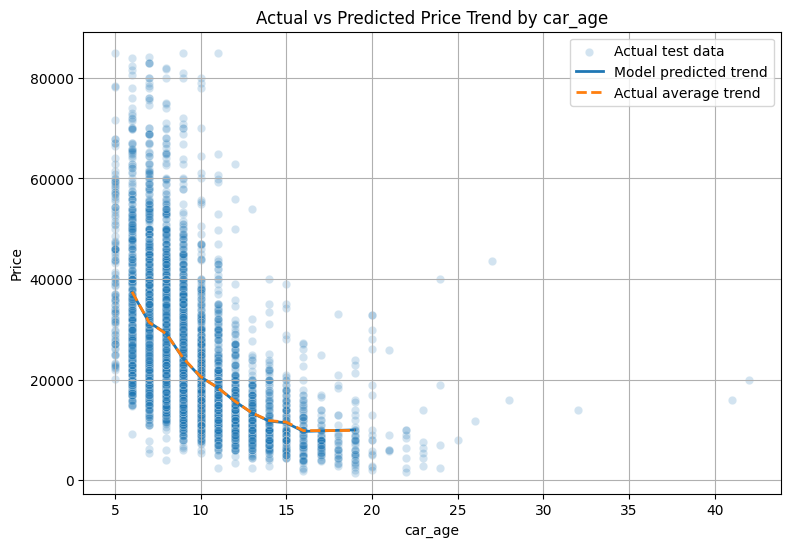

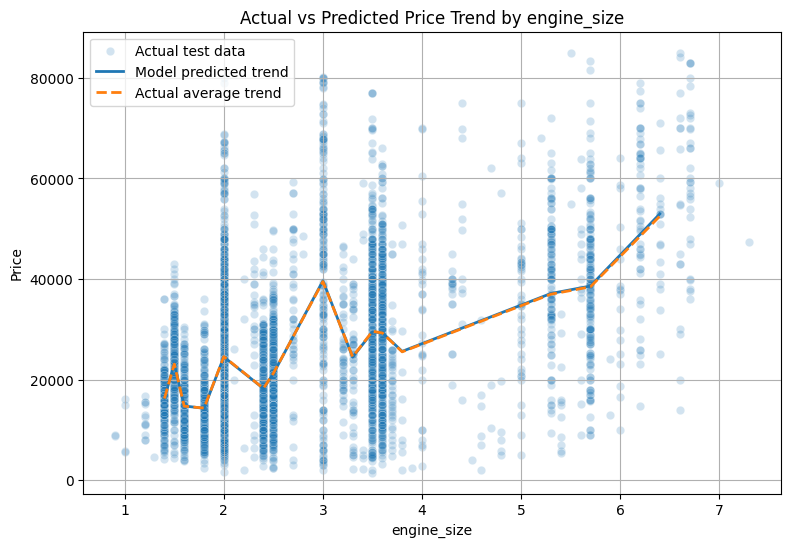

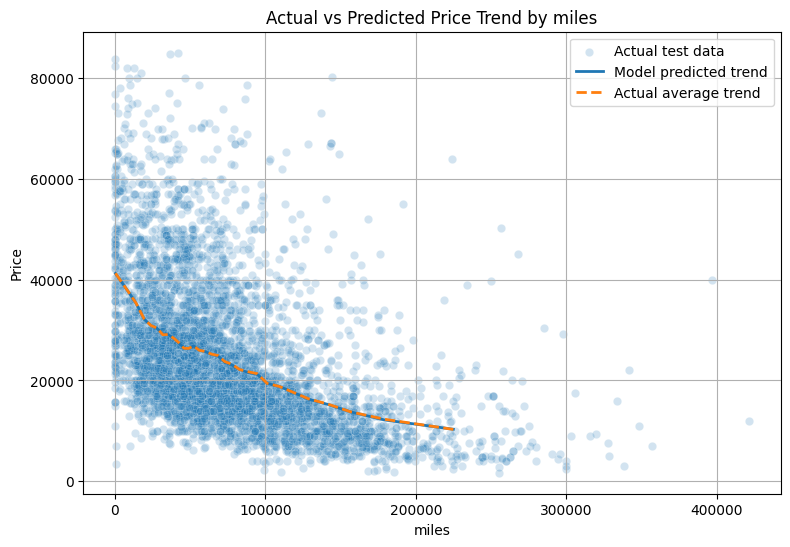

In [ ]:
preprocessor_fitted = best_model.named_steps["preprocessor"]

encoded_feature_names = preprocessor_fitted.get_feature_names_out()

print("Total transformed feature columns:", len(encoded_feature_names))

features = ["car_age", "engine_size", "miles"]

for feature in features:
    plot_df = comparison_df[
        [feature, "actual_price", "predicted_price"]
    ].dropna().copy()

    # Remove extreme prices for cleaner visualization
    price_99 = plot_df["actual_price"].quantile(0.99)

    plot_df = plot_df[
        (plot_df["actual_price"] <= price_99)
        & (plot_df["predicted_price"] <= price_99)
    ].copy()

    # Sample actual points
    sample_df = plot_df.sample(
        min(len(plot_df), 5000),
        random_state=42
    )

    # Bin feature for smoother trend line
    plot_df["feature_bin"] = pd.qcut(
        plot_df[feature],
        q=30,
        duplicates="drop"
    )

    trend_df = (
        plot_df
        .groupby("feature_bin", observed=True)
        .agg(
            feature_median=(feature, "median"),
            actual_mean=("actual_price", "mean"),
            predicted_mean=("predicted_price", "mean")
        )
        .reset_index()
        .sort_values("feature_median")
    )

    plt.figure(figsize=(9, 6))

    sns.scatterplot(
        data=sample_df,
        x=feature,
        y="actual_price",
        alpha=0.2,
        label="Actual test data"
    )

    plt.plot(
        trend_df["feature_median"],
        trend_df["predicted_mean"],
        linewidth=2,
        label="Model predicted trend"
    )

    plt.plot(
        trend_df["feature_median"],
        trend_df["actual_mean"],
        linestyle="--",
        linewidth=2,
        label="Actual average trend"
    )

    plt.title(f"Actual vs Predicted Price Trend by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

## Residual Analysis 

residual = actual price - predicted price

Positive residuals indicate that the model underpredicted and negative residuals indicate that the model overpredicted

In [ ]:
preds = best_model.predict(X_test)

residual_df = X_test.copy()
residual_df["actual_price"] = y_test.values
residual_df["predicted_price"] = preds
residual_df["residual"] = residual_df["actual_price"] - residual_df["predicted_price"]
residual_df["absolute_error"] = residual_df["residual"].abs()
residual_df["absolute_percent_error"] = (
    residual_df["absolute_error"] / residual_df["actual_price"]
) * 100

residual_df.head()

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.8s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    7.4s finished


,miles,year,make,body_type,vehicle_type,drivetrain,transmission,fuel_type,engine_size,engine_block,...,miles_was_zero,car_age,miles_per_year,model_trim,region,actual_price,predicted_price,residual,absolute_error,absolute_percent_error
122329,136712.0,2014.0,nissan,cargo van,truck,rwd,automatic,unleaded,4.0,v,...,0,12.0,11392.666667,nv cargo sv,l6v,16995.0,21012.000000,-4017.000000,4017.000000,23.636364
241204,72712.0,2017.0,nissan,hatchback,car,fwd,automatic,unleaded,2.0,i,...,0,9.0,8079.111111,rogue sport s,j7k,16495.0,15184.033333,1310.966667,1310.966667,7.947661
172935,32441.0,2020.0,kia,sedan,car,fwd,automatic,unleaded,2.0,i,...,0,6.0,5406.833333,spectra ex,l4l,18988.0,18665.813333,322.186667,322.186667,1.696791
335605,59110.0,2017.0,audi,sedan,car,4wd,automatic,premium unleaded,2.0,i,...,0,9.0,6567.777778,a3 sedan prestige,k1t,28995.0,32515.463333,-3520.463333,3520.463333,12.141622
316761,19416.0,2018.0,acura,suv,truck,4wd,automatic,premium unleaded,3.5,v,...,0,8.0,2427.000000,mdx advance package,r3t,43990.0,44636.860000,-646.860000,646.860000,1.470471


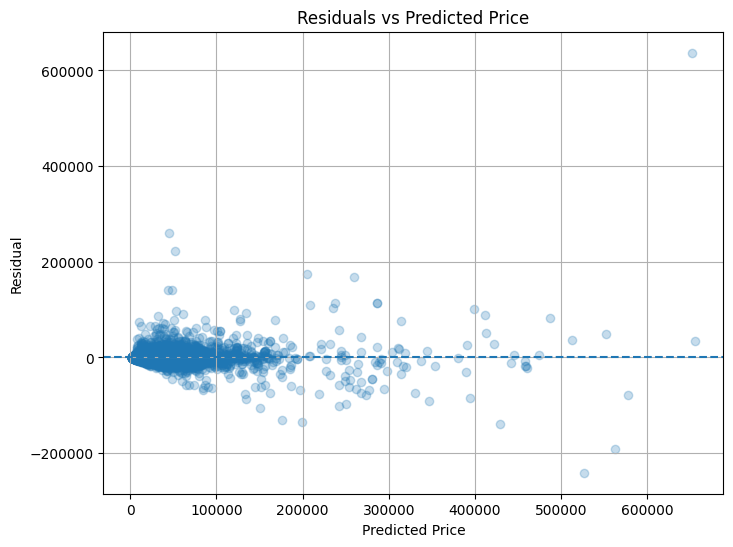

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(residual_df["predicted_price"], residual_df["residual"], alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price")
plt.grid(True)
plt.show()

In [ ]:
within_1000 = (residual_df["absolute_error"] <= 1000).mean() * 100
within_2500 = (residual_df["absolute_error"] <= 2500).mean() * 100
within_5000 = (residual_df["absolute_error"] <= 5000).mean() * 100
within_10_percent = (residual_df["absolute_percent_error"] <= 10).mean() * 100
within_20_percent = (residual_df["absolute_percent_error"] <= 20).mean() * 100

print("Within $1,000:", within_1000)
print("Within $2,500:", within_2500)
print("Within $5,000:", within_5000)
print("Within 10%:", within_10_percent)
print("Within 20%:", within_20_percent)

Within $1,000: 59.77792347287514
Within $2,500: 83.3902939166097
Within $5,000: 94.34765020157072
Within 10%: 79.35469471452285
Within 20%: 92.25522061182642


In [ ]:
train_preds = best_model.predict(X_train)
test_preds = best_model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
test_r2 = r2_score(y_test, test_preds)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Train R2:", train_r2)
print("Test R2:", test_r2)

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.6s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    4.5s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:   13.2s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=12)]: Done 138 tasks      | elapsed:    1.6s


Train MAE: 739.5293793560452
Test MAE: 1610.9220002159852
Train RMSE: 2692.939667666137
Test RMSE: 5139.042976435848
Train R2: 0.9831288745963911
Test R2: 0.9357034566436193


[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    3.1s finished


## Save final model pipeline

I save the full pipeline, not just the regressor. This matters because the pipeline contains both preprocessing and the model.

The saved `.joblib` file can later be loaded in a Django backend to make predictions from user-submitted vehicle features.


In [ ]:
best_model = fitted_models["Random Forest"]

In [ ]:
import joblib
from pathlib import Path

Path("../models").mkdir(exist_ok=True)

joblib.dump(best_model, "../models/random_forest_best_pipeline.joblib")
joblib.dump(X_train.columns.tolist(), "../models/expected_columns.joblib")

print("Best Random Forest pipeline saved.")

Best Random Forest pipeline saved.


In [ ]:
results_df.to_csv("../models/model_comparison_results.csv", index=False)

# Conclusion 

The Random Forest model performed best, achieving a test MAE of about $1,611 and an R² of 0.936, far outperforming the dummy baseline MAE of about $11,000. Using model_trim, location features, and frequency-controlled one-hot encoding helped reduce the feature space while preserving important pricing information. Although the model generalizes well, the full saved Random Forest artifact is very large, so the next step is to perform error analysis and test smaller Random Forest versions to create a deployment-ready mode